# Базовый опыт агентной модели SIR

Модель запускается с параметрами методического пособия. Для сопоставления
теории и эксперимента вычисляется $R_0=\beta/\gamma$, где
$\gamma=1/T_{inf}$, а затем измеряются день и величина фактического пика.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames, JLD2
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Параметры и расчёт

In [2]:
params = (
    Ns=[1000, 1000, 1000], β_und=[0.5, 0.5, 0.5], β_det=[0.05, 0.05, 0.05],
    infection_period=14, detection_time=7, death_rate=0.02,
    reinfection_probability=0.1, Is=[0, 0, 1], seed=42,
)
model, history_rows = run_sir(; params..., n_steps=100)
trajectory = save_frame(DataFrame(history_rows), "sir-run-basic", "trajectory.csv")
metrics = DataFrame([merge(epidemic_metrics(trajectory, sum(params.Ns)),
    (R0=basic_reproduction_number(params.β_und[1], params.infection_period),))])
save_frame(metrics, "sir-run-basic", "summary.csv")
jldsave(scenario_data("sir-run-basic", "sir_basic_agent.jld2"); trajectory)
jldsave(scenario_data("sir-run-basic", "sir_basic_model.jld2"); metrics)

## Визуализация

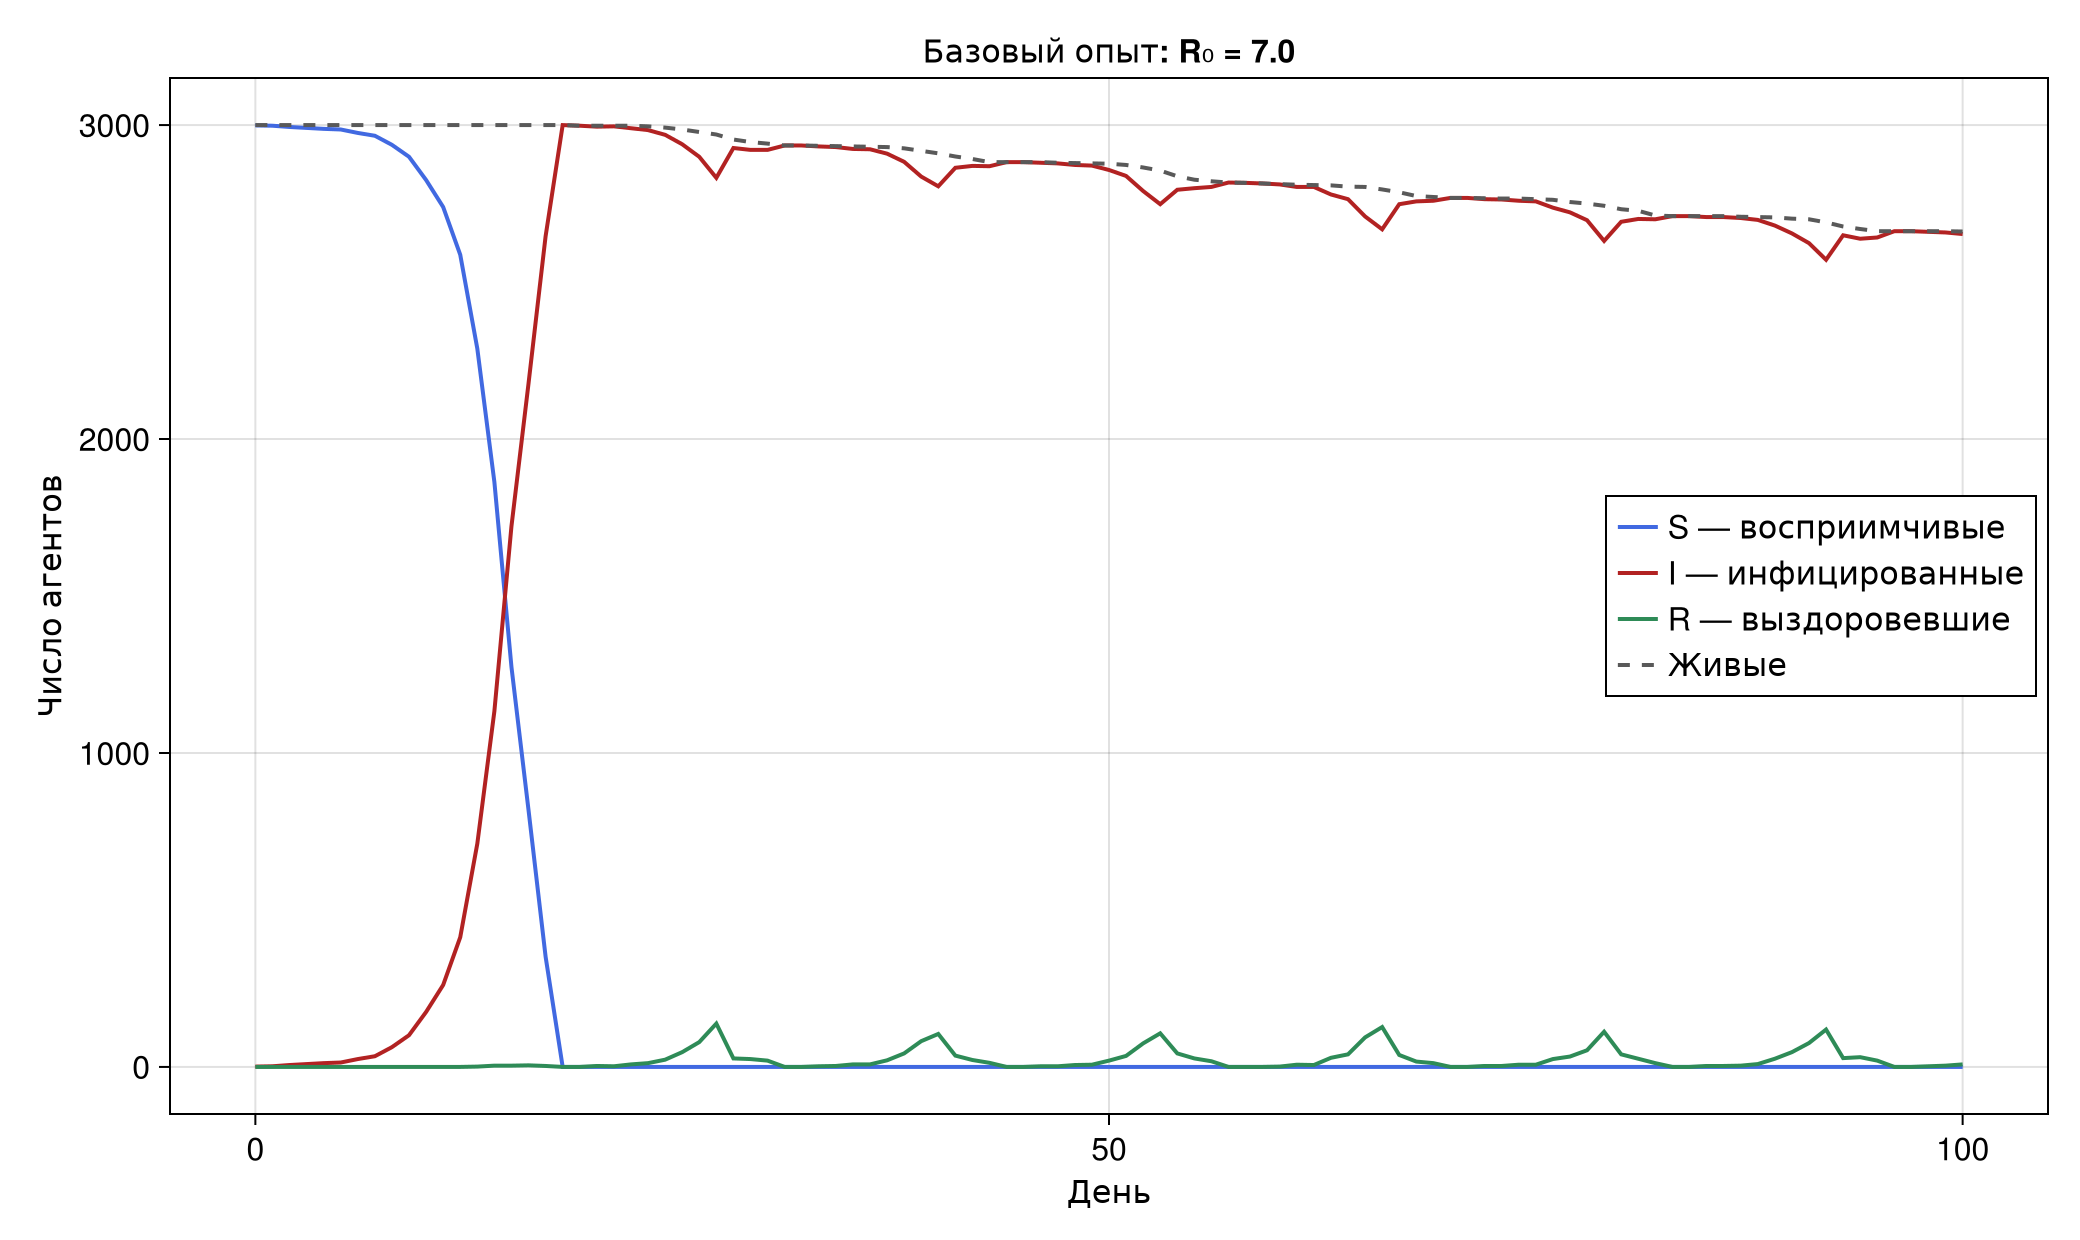

Row,peak_fraction,peak_day,final_infected,final_recovered,deaths,attack_rate,R0
,Float64,Int64,Float64,Float64,Int64,Float64,Float64
1,1.0,18,0.996994,0.00266667,339,1.0,7.0


In [3]:
fig = sir_figure(trajectory; title="Базовый опыт: R₀ = $(metrics.R0[1])")
save_figure(fig, "sir-run-basic", "sir-basic-dynamics.png";
            report_name="sir-baseline-dynamics.png")
display(fig)
metrics